In [1]:
from functions.cleaning_functions import convert_mmcif_to_pdb
from MDAnalysis.coordinates.memory import MemoryReader
from MDAnalysis.analysis import pca, align
from Bio.PDB import MMCIFParser, PDBIO
import MDAnalysis as mda
import pandas as pd
import numpy as np
import glob
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib 
import nglview as nv
import os.path


c:\Users\maxvV\anaconda3\envs\biomolsim\Lib\site-packages\Bio\Application\__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


# Used Fullstory

In [2]:

def make_pca_plot_S(targetlist,SELEC,plot=True):
    for target in targetlist:
        if not os.path.exists(target[:-3]+"pdb"):
            convert_mmcif_to_pdb(target)

    file_list = [target[:-3]+"pdb" for target in targetlist]
    print("PDB tranlation done")
   
    universe_list = [mda.Universe(path).select_atoms(SELEC) for  path in file_list]
    # Stack coordinates into a (2, n_atoms, 3) array
    coords = np.stack([item.atoms.positions.copy() for item in universe_list], axis=0)
    
    u = mda.Universe(file_list[0])
    u.trajectory = MemoryReader(coords)

    # Do the PCA

    pc = pca.PCA(u, select=SELEC,
                align=True, mean=None,
                n_components=10).run()

    backbone = u.select_atoms(SELEC)
   
    # Turn into DF

    transformed = pc.transform(backbone, n_components=3)
    df = pd.DataFrame(transformed,
                    columns=['PC{}'.format(i+1) for i in range(3)])
    
    df['Time (ps)'] = df.index * u.trajectory.dt
    #df["name"]= [(path.split("seed")[-1].split("_")[1]) for path in targetlist]
    df["name"]= ['_'.join(path.split("fold_")[-1].split("_model")[0].split("_")[-2:]) for path in targetlist]
    #df["name"] = ["np","np_X","np","np","np","np_c_X","np_c","np_c","np_c","np_c","p_c_X","p_c","p_c","p_c","p_c","p","p","p","p_X","p"]
    
    if plot:
        sns.scatterplot(df,x="PC1",y="PC2",hue='name')
        plt.legend(bbox_to_anchor=(1.4,1))

    print("Finished PCA")
    return pc,u,df

In [12]:
story = glob.glob("cif_files/Predictions/SEEDMATCHED/*seed1_noptms/*cif")+glob.glob("cif_files/Predictions/TMTC3/*noptm_m*cif")+glob.glob("cif_files/Predictions/TMTC3/*3_m*cif")+glob.glob("cif_files/Predictions/SEEDMATCHED/*seed42_ptms/*cif") 
pc,u,pca_df = make_pca_plot_S(story,SELEC="index 0:1700",plot=False)

PDB tranlation done
Finished PCA


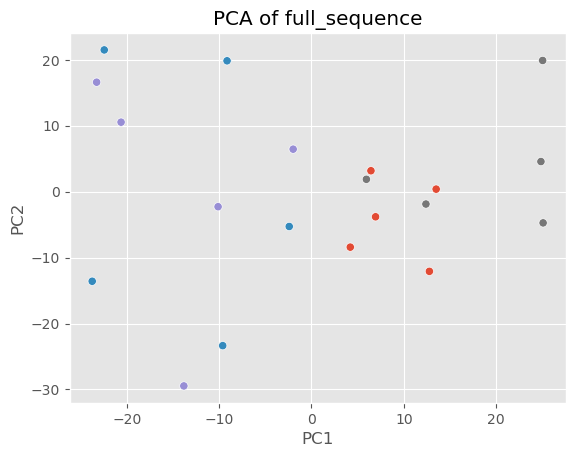

In [13]:
plt.style.use('ggplot')
plt.title("PCA of full_sequence")
sns.scatterplot(pca_df,x="PC1",y="PC2",hue='name')
plt.legend().remove()

Cumulated variance 1: 0.320
Cumulated variance 2: 0.550
Cumulated variance 3: 0.661


c:\Users\maxvV\anaconda3\envs\biomolsim\Lib\site-packages\MDAnalysis\analysis\pca.py:370: DeprecationWarning: The `cumulated_variance` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.cumulated_variance` instead.
  warnings.warn(wmsg, DeprecationWarning)


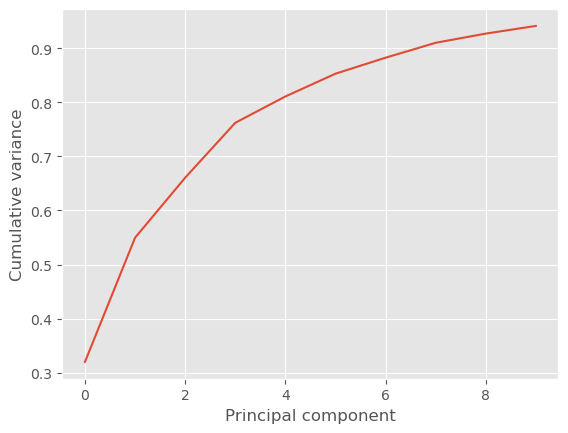

In [14]:
for i in range(3):
    print(f"Cumulated variance {i+1}: {pc.cumulated_variance[i]:.3f}")
plt.plot(pc.cumulated_variance[:10])
plt.xlabel('Principal component')
plt.ylabel('Cumulative variance')
plt.show()

In [16]:

backbone = u.select_atoms("index 0:1700")
transformed = pc.transform(backbone, n_components=3)

pc1 = pc.p_components[:, 0]
trans1 = transformed[:, 0]
projected = np.outer(trans1, pc1) + pc.mean.flatten()
coordinates = projected.reshape(len(trans1), -1, 3)
proj1 = mda.Merge(backbone)
proj1.load_new(coordinates, order="fac")
view = nv.show_mdanalysis(proj1.atoms)
view

c:\Users\maxvV\anaconda3\envs\biomolsim\Lib\site-packages\MDAnalysis\analysis\pca.py:350: DeprecationWarning: The `p_components` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.p_components` instead.
  warnings.warn(wmsg, DeprecationWarning)


NGLWidget(max_frame=19)

In [17]:
pc1

array([ 0.01199071, -0.02660252,  0.01584259, ...,  0.00807716,
        0.01399319, -0.018358  ])

In [9]:
for i in range(3):
    cc = pca.cosine_content(transformed, i)
    print(f"Cosine content for PC {i+1} = {cc:.3f}")

Cosine content for PC 1 = 0.055
Cosine content for PC 2 = 0.151
Cosine content for PC 3 = 0.091


In [10]:
df = pd.DataFrame(transformed,
                  columns=['PC{}'.format(i+1) for i in range(3)])
df['Time (ps)'] = df.index * u.trajectory.dt
df.head()

,PC1,PC2,PC3,Time (ps)
0,-122.324734,-8.334128,24.552642,0
1,50.476087,16.550326,-49.288108,1
2,23.165313,-74.491083,0.562928,2
3,-34.319494,-3.162804,8.408390,3
4,-37.443437,-37.012610,-5.030266,4


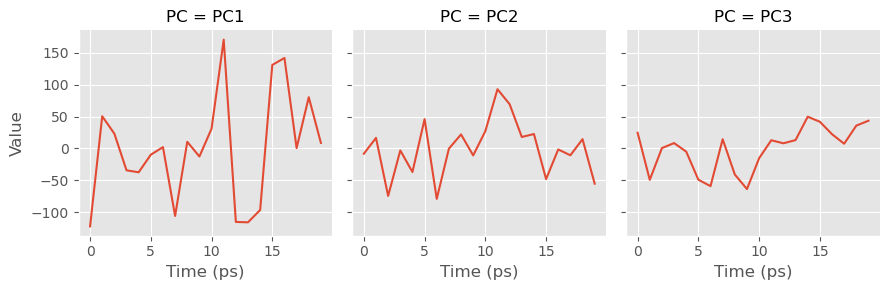

In [11]:
# melt the dataframe into a tidy format
melted = pd.melt(df, id_vars=["Time (ps)"],
                 var_name="PC",
                 value_name="Value")
g = sns.FacetGrid(melted, col="PC")
g.map(sns.lineplot,
      "Time (ps)", # x-axis
      "Value") # no confidence interval
plt.show()

In [12]:
proj1.atoms.write("pcatraj/ALLstory_pc2.pdb")
with mda.Writer("pcatraj/ALLstory_pc2.dcd", proj1.atoms.n_atoms) as W:
    for ts in proj1.trajectory:
        W.write(proj1.atoms)

c:\Users\maxvV\anaconda3\envs\biomolsim\Lib\site-packages\MDAnalysis\coordinates\PDB.py:777: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn("Unit cell dimensions not found. "
c:\Users\maxvV\anaconda3\envs\biomolsim\Lib\site-packages\MDAnalysis\coordinates\PDB.py:1154: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"
c:\Users\maxvV\anaconda3\envs\biomolsim\Lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)


In [3]:
story = glob.glob("cif_files/Predictions/SEEDMATCHED/*seed1_noptms/*cif")+glob.glob("cif_files/Predictions/TMTC3/*noptm_m*cif")+glob.glob("cif_files/Predictions/TMTC3/*3_m*cif")+glob.glob("cif_files/Predictions/SEEDMATCHED/*seed42_ptms/*cif") 
pc2,u2,df2 = make_pca_plot_S(story,SELEC="index 0:1700",plot=False)

PDB tranlation done
Finished PCA


NameError: name 'df' is not defined

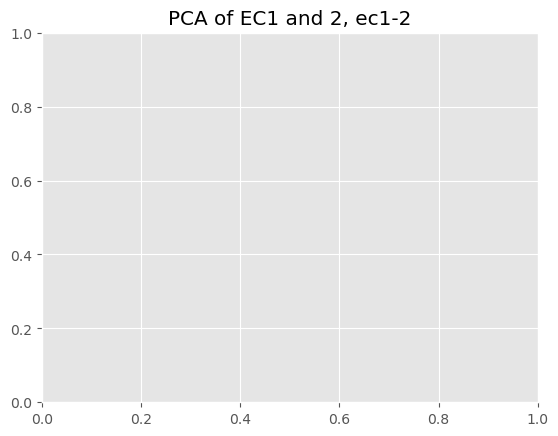

In [4]:
plt.style.use('ggplot')
plt.title("PCA of EC1 and 2, ec1-2")
sns.scatterplot(df,x="PC1",y="PC2",hue='name')
#plt.legend(bbox_to_anchor=(1.4,1))
plt.legend().remove()

# PCA Reworked 

## PDB making

In [5]:

targetlist = glob.glob("cif_files/Predictions/SEEDMATCHED/*seed1_noptms/*pdb")+glob.glob("cif_files/Predictions/TMTC3/*noptm_m*pdb")+glob.glob("cif_files/Predictions/TMTC3/*3_m*pdb")+glob.glob("cif_files/Predictions/SEEDMATCHED/*seed42_ptms/*pdb") 

if len(targetlist) == 0:
    for target in targetlist:
        convert_mmcif_to_pdb(target[:-3]+"cif")

file_list_p = [target[:-3]+"pdb" for target in targetlist]

targetlist2 = glob.glob("cif_files/Predictions/notemplate/*seed1*/*pdb")+glob.glob("cif_files/Predictions/notemplate/*tmtc3_nop*/*pdb")+glob.glob("cif_files/Predictions/notemplate/*tmtc3_not*/*pdb")+glob.glob("cif_files/Predictions/notemplate/*_ptm_*/*pdb")
if len(targetlist2) == 0:
    for target2 in targetlist2:
        convert_mmcif_to_pdb(target2[:-3]+"cif")
file_list2 = [target2[:-3]+"pdb" for target2 in targetlist2]

# take out model 4
model4_list = [file_list_p[item] for item in [4,9,14,19]]
file_list = [item for item in file_list_p if item not in model4_list]

In [6]:
from functions.pca_functions import pca_on_traj

In [7]:
u = mda.Universe(file_list[0])
view = nv.show_mdanalysis(u.select_atoms("index 500:1000").atoms)
view

NGLWidget()

In [8]:

df = pca_on_traj([file_list,file_list2,model4_list],
            listnames=["Template","NoTemplate","model4"],
            selec="index 1:1700")

plt.style.use('ggplot')
plt.title("PCA of EC1-2")
sns.scatterplot(df,x="PC1",y="PC2",hue="list",style="list")
plt.legend(bbox_to_anchor=(1,1));


IndexError: index 1700 is out of bounds for axis 0 with size 1700

In [ ]:
df = pca_on_traj([file_list_p[:5]+file_list_p[-5:]],
            listnames=["Template"],
            selec="index 0:1200")

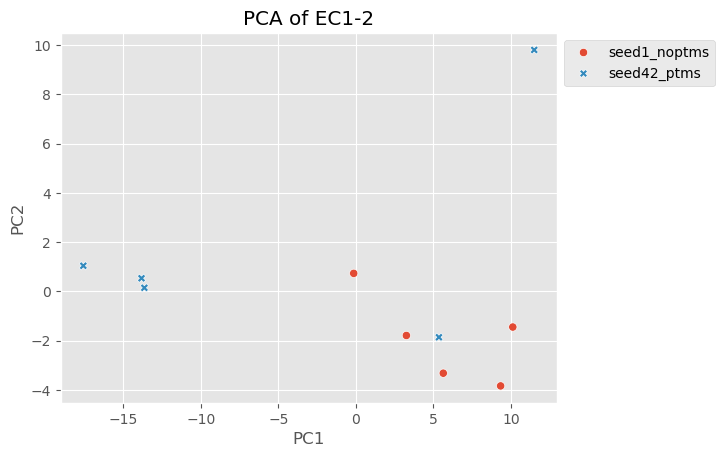

In [ ]:
plt.style.use('ggplot')
plt.title("PCA of EC1-2")
sns.scatterplot(df,x="PC1",y="PC2",hue="name",style="name")
plt.legend(bbox_to_anchor=(1,1));